#### Parsing des logs et construction des sessions
:parser les logs bruts avec Drain3, construire les sessions par `block_id`, attribuer les labels et préparer la division train/test partagée.  

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
import pickle
import os
from collections import Counter
from tqdm.notebook import tqdm

# Chemins
DATA_DIR = "../data/"
OUTPUT_DIR = "../outputs/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

LOG_PATH = os.path.join(DATA_DIR, "HDFS.log")
print(f"Fichier de log : {LOG_PATH}")
print(f"Taille : {os.path.getsize(LOG_PATH)/1024/1024:.0f} MB")

Fichier de log : ../data/HDFS.log
Taille : 1505 MB


#### 1. Parsing des lignes de log brutes
Extraction des champs structurés à partir de chaque ligne de log.


| Motif | Description |
| :--- | :--- |
| `\d{6}` | **Exactement 6 chiffres** (Date YYMMDD, Heure HHMMSS) |
| `\d+` | **Au moins un chiffre** (Le PID peut avoir un nombre de chiffres variable) |
| `\s` | **Un seul espace** (Séparateur de champs) |
| `\S+?` | **Au moins un caractère non-espace**, correspondance minimale (S'arrête dès qu'il rencontre `:`) |
| `(.+)$` | **Capture tout le reste** jusqu'à la fin de la ligne |
| `()` | **Groupes de capture** (Permet d'extraire chaque champ avec `match.groups()`) |

In [3]:
# Expressions régulières pour le parsing
LOG_PATTERN = re.compile(
    r'^(\d{6})\s(\d{6})\s(\d+)\s(INFO|WARN|ERROR|FATAL)\s(\S+?):\s(.+)$'
)
BLOCK_PATTERN = re.compile(r'(blk_-?\d+)')

def parse_log_line(line):
    """
    Analyse une ligne de log brute et retourne un dictionnaire structuré.
    Retourne None si la ligne ne correspond pas au format attendu.
    """
    line = line.strip()
    match = LOG_PATTERN.match(line)
    if not match:
        return None
    
    date, time_str, pid, level, component, content = match.groups()
    block_ids = BLOCK_PATTERN.findall(content)
    
    return {
        'date': date,
        'time': time_str,
        'timestamp': f"{date}_{time_str}",
        'pid': int(pid),
        'level': level,
        'component': component,
        'content': content,
        'block_ids': block_ids,
        'raw': line
    }


#### 1.1 Test rapide sur quelques lignes


In [4]:
# Test de la fonction de parsing sur les 5 premières lignes
with open(LOG_PATH, 'r') as f:
    for i in range(5):
        line = f.readline()
        result = parse_log_line(line)
        if result:
            print(f"[Ligne {i}]")
            print(f"  Date      : {result['date']}")
            print(f"  Heure     : {result['time']}")
            print(f"  Niveau    : {result['level']}")
            print(f"  Composant : {result['component']}")
            print(f"  Block IDs : {result['block_ids']}")
            print(f"  Contenu   : {result['content'][:80]}...")
            print()


[Ligne 0]
  Date      : 081109
  Heure     : 203518
  Niveau    : INFO
  Composant : dfs.DataNode$DataXceiver
  Block IDs : ['blk_-1608999687919862906']
  Contenu   : Receiving block blk_-1608999687919862906 src: /10.250.19.102:54106 dest: /10.250...

[Ligne 1]
  Date      : 081109
  Heure     : 203518
  Niveau    : INFO
  Composant : dfs.FSNamesystem
  Block IDs : ['blk_-1608999687919862906']
  Contenu   : BLOCK* NameSystem.allocateBlock: /mnt/hadoop/mapred/system/job_200811092030_0001...

[Ligne 2]
  Date      : 081109
  Heure     : 203519
  Niveau    : INFO
  Composant : dfs.DataNode$DataXceiver
  Block IDs : ['blk_-1608999687919862906']
  Contenu   : Receiving block blk_-1608999687919862906 src: /10.250.10.6:40524 dest: /10.250.1...

[Ligne 3]
  Date      : 081109
  Heure     : 203519
  Niveau    : INFO
  Composant : dfs.DataNode$DataXceiver
  Block IDs : ['blk_-1608999687919862906']
  Contenu   : Receiving block blk_-1608999687919862906 src: /10.250.14.224:42420 dest: /10.250...



### 1.2 Parsing complet du fichier

In [5]:
# Parsing de l'intégralité du fichier de log
print("Parsing en cours...")

parsed_lines = []
failed_lines = []
line_count = 0

with open(LOG_PATH, 'r') as f:
    for line in tqdm(f, desc="Parsing HDFS.log", total=11175629):
        line_count += 1
        result = parse_log_line(line)
        if result:
            parsed_lines.append(result)
        else:
            failed_lines.append(line.strip())

print(f"\nRésultat du parsing :")
print(f"  Lignes réussies : {len(parsed_lines):,}")
print(f"  Lignes échouées : {len(failed_lines):,}")
print(f"  Taux d'échec :    {len(failed_lines)/line_count*100:.4f}%")


Parsing en cours...


Parsing HDFS.log:   0%|          | 0/11175629 [00:00<?, ?it/s]


Résultat du parsing :
  Lignes réussies : 11,175,629
  Lignes échouées : 0
  Taux d'échec :    0.0000%


In [7]:
# Vérification des lignes échouées (le cas échéant)
if failed_lines:
    print(f"Exemples de lignes non parsées (max 5) :\n")
    for line in failed_lines[:5]:
        print(f" {line[:120]}")
else:
    print("toutes les lignes ont été parsées avec succès")


toutes les lignes ont été parsées avec succès


#### 2. Extraction des templates avec Drain3
Drain3 regroupe les messages de log similaires en **templates** (types d'événements).

**Exemple de fonctionnement :**
```
"Receiving block blk_123 src: /10.0.0.1 dest: /10.0.0.2"
"Receiving block blk_456 src: /10.0.0.3 dest: /10.0.0.4"
→ Template : "Receiving block <*> src: <*> dest: <*>"  (= E5)
```


In [9]:
from drain3 import TemplateMiner
from drain3.template_miner_config import TemplateMinerConfig

config = TemplateMinerConfig()
config.drain_depth = 4
config.drain_sim_th = 0.4
config.profiling_enabled = False

template_miner = TemplateMiner(config=config)


### 2.1 Alimentation de Drain3


In [10]:
# Alimentation de Drain3 avec le contenu de chaque ligne parsée
print("==== Extraction des templates en cours ====")

for line_data in tqdm(parsed_lines, desc="Drain3"):
    template_miner.add_log_message(line_data['content'])

clusters = template_miner.drain.clusters
print(f"\n Nombre de templates extraits : {len(clusters)}")


==== Extraction des templates en cours ====


Drain3:   0%|          | 0/11175629 [00:00<?, ?it/s]


 Nombre de templates extraits : 47


### 2.2 Liste des templates extraits


In [8]:
# Affichage de tous les templates triés par fréquence
print(f"{'ID':>5} | {'Occurrences':>12} | Template")
print("-" * 90)

template_mapping = {}

for cluster in sorted(clusters, key=lambda c: c.size, reverse=True):
    eid = f"E{cluster.cluster_id}"
    template = cluster.get_template()
    template_mapping[cluster.cluster_id] = template
    print(f"{eid:>5} | {cluster.size:>12,} | {template}")


   ID |  Occurrences | Template
------------------------------------------------------------------------------------------
   E1 |    1,723,232 | Receiving block <*> src: <*> dest: <*>
   E5 |    1,719,741 | BLOCK* NameSystem.addStoredBlock: blockMap updated: <*> is added to <*> size <*>
   E3 |    1,706,728 | PacketResponder <*> for block <*> <*>
   E4 |    1,706,514 | Received block <*> of size <*> from <*>
  E17 |    1,402,047 | Deleting block <*> file <*>
  E32 |    1,396,174 | BLOCK* NameSystem.delete: <*> is added to invalidSet of <*>
   E2 |      575,061 | BLOCK* NameSystem.allocateBlock: <*> <*>
  E10 |      428,726 | <*> Served block <*> to <*>
  E35 |      356,207 | <*> exception while serving <*> to <*>
  E13 |      120,036 | Verification succeeded for <*>
   E6 |        7,097 | Received block <*> src: <*> dest: <*> of size <*>
   E7 |        6,937 | <*> block <*> to <*>
  E11 |        6,837 | BLOCK* ask <*> to replicate <*> to datanode(s) <*>
  E12 |        6,837 | <*> Star

### 2.3 Validation par rapport au fichier de référence


In [12]:
templates_path = os.path.join(DATA_DIR, "HDFS.log_templates.csv")
if os.path.exists(templates_path):
    ref_templates = pd.read_csv(templates_path)
    display(ref_templates)


,EventId,EventTemplate
0,E1,[*]Adding an already existing block[*]
1,E2,[*]Verification succeeded for[*]
2,E3,[*]Served block[*]to[*]
3,E4,[*]Got exception while serving[*]to[*]
4,E5,[*]Receiving block[*]src:[*]dest:[*]
5,E6,[*]Received block[*]src:[*]dest:[*]of size[*]
6,E7,[*]writeBlock[*]received exception[*]
7,E8,[*]PacketResponder[*]for block[*]Interrupted[*]
8,E9,[*]Received block[*]of size[*]from[*]
9,E10,[*]PacketResponder[*]Exception[*]


In [10]:
# Sauvegarde du mapping des templates
template_map_output = {str(cid): tmpl for cid, tmpl in template_mapping.items()}

with open(os.path.join(OUTPUT_DIR, "template_mapping.json"), 'w') as f:
    json.dump(template_map_output, f, indent=2, ensure_ascii=False)

print(f" template_mapping.json sauvegardé ({len(template_mapping)} templates)")


 template_mapping.json sauvegardé (47 templates)


#### 3. Construction des sessions par block_id
On regroupe toutes les lignes de log partageant le même `block_id` en une **session**.  
Chaque session représente le cycle de vie complet d'un bloc HDFS.


In [13]:
# Regroupement des lignes par block_id
print("Regroupement par block_id en cours...")

sessions_raw = {}
no_block_count = 0

for line_data in tqdm(parsed_lines, desc="Regroupement"):
    if not line_data['block_ids']:
        no_block_count += 1
        continue
    
    # Une ligne peut contenir plusieurs block_id
    for bid in line_data['block_ids']:
        if bid not in sessions_raw:
            sessions_raw[bid] = []
        sessions_raw[bid].append(line_data)

# Tri chronologique au sein de chaque session
for bid in sessions_raw:
    sessions_raw[bid].sort(key=lambda x: x['timestamp'])

print(f"\nNombre total de sessions :  {len(sessions_raw):,}")
print(f"Lignes sans block_id :      {no_block_count:,}")


Regroupement par block_id en cours...


Regroupement:   0%|          | 0/11175629 [00:00<?, ?it/s]


Nombre total de sessions :  575,061
Lignes sans block_id :      0


### 3.1 Statistiques de longueur des sessions


Statistiques de longueur des sessions :
  Minimum :    2
  Maximum :    310
  Moyenne :    21.87
  Médiane :    22.00
  Écart-type : 6.03


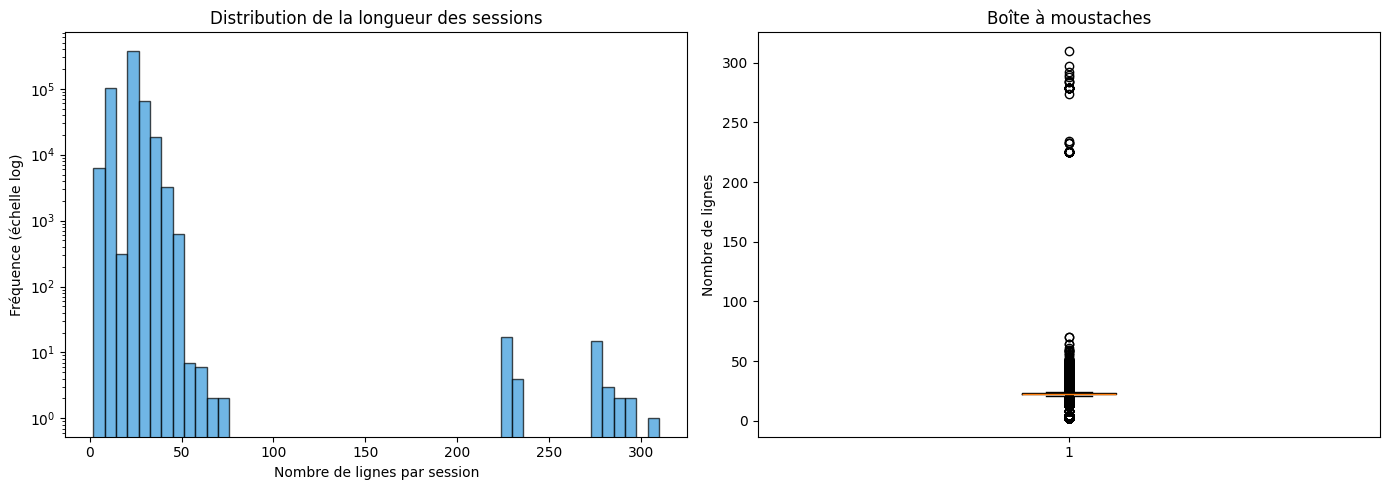

In [13]:
# Distribution de la longueur des sessions
session_lengths = [len(events) for events in sessions_raw.values()]

print("Statistiques de longueur des sessions :")
print(f"  Minimum :    {min(session_lengths)}")
print(f"  Maximum :    {max(session_lengths)}")
print(f"  Moyenne :    {np.mean(session_lengths):.2f}")
print(f"  Médiane :    {np.median(session_lengths):.2f}")
print(f"  Écart-type : {np.std(session_lengths):.2f}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(session_lengths, bins=50, edgecolor='black', alpha=0.7, color='#3498db')
axes[0].set_title('Distribution de la longueur des sessions')
axes[0].set_xlabel('Nombre de lignes par session')
axes[0].set_ylabel('Fréquence (échelle log)')
axes[0].set_yscale('log')

axes[1].boxplot(session_lengths, vert=True)
axes[1].set_title('Boîte à moustaches')
axes[1].set_ylabel('Nombre de lignes')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "session_length_distribution.png"))
plt.show()


#### 4. Attribution des labels et des Event IDs
On associe à chaque session :
- Son **label** (Normal/Anomaly) depuis `anomaly_label.csv`
- La **séquence d'Event IDs** via le matching Drain3


In [15]:
# Chargement des étiquettes
labels_df = pd.read_csv(os.path.join(DATA_DIR, "anomaly_label.csv"))
label_dict = dict(zip(labels_df['BlockId'], labels_df['Label']))
print(f"Étiquettes disponibles : {len(label_dict):,}")


Étiquettes disponibles : 575,061


In [16]:
# Construction des sessions enrichies (event_id + label)

enriched_sessions = {}
unmatched = 0

for bid, events in tqdm(sessions_raw.items(), desc="Enrichissement"):
    # Vérification de l'existence du label
    if bid not in label_dict:
        unmatched += 1
        continue
    
    # Attribution de l'event_id via Drain3
    event_sequence = []
    for event in events:
        result = template_miner.match(event['content'])
        event_id = f"E{result.cluster_id}" if result else "E_UNKNOWN"
        
        event_sequence.append({
            'event_id': event_id,
            'content': event['content'],
            'timestamp': event['timestamp'],
            'level': event['level']
        })
    
    enriched_sessions[bid] = {
        'events': event_sequence,
        'label': label_dict[bid],
        'sequence_str': ' '.join([e['event_id'] for e in event_sequence])
    }

print(f"\nSessions enrichies : {len(enriched_sessions):,}")
print(f"Sessions sans label : {unmatched:,}")

# Distribution
labels_list = [v['label'] for v in enriched_sessions.values()]
n_normal = labels_list.count('Normal')
n_anomaly = labels_list.count('Anomaly')
print(f"\nDistribution :")
print(f"  Normal  : {n_normal:,}")
print(f"  Anomaly : {n_anomaly:,} ({n_anomaly/len(labels_list)*100:.2f}%)")


Enrichissement:   0%|          | 0/575061 [00:00<?, ?it/s]


Sessions enrichies : 575,061
Sessions sans label : 0

Distribution :
  Normal  : 558,223
  Anomaly : 16,838 (2.93%)


### 4.1 Comparaison des séquences normales vs anormales
on peut observer concrètement les anomalies sémantiques :  
les événements individuels sont souvent identiques, mais c'est la **séquence** qui diffère.


In [17]:
# Exemples de sessions normales
print("=" * 75)
print("EXEMPLES DE SESSIONS NORMALES")
print("=" * 75)

normal_bids = [b for b, s in enriched_sessions.items() if s['label'] == 'Normal']
for bid in normal_bids[:3]:
    s = enriched_sessions[bid]
    print(f"\n {bid}  [{len(s['events'])} événements]")
    print(f"   Séquence : {s['sequence_str']}")
    for e in s['events'][:3]:
        print(f"   → [{e['event_id']}] {e['content'][:70]}...")
    if len(s['events']) > 3:
        print(f"   ... ({len(s['events'])-3} événements supplémentaires)")


EXEMPLES DE SESSIONS NORMALES

 blk_-1608999687919862906  [279 événements]
   Séquence : E1 E2 E1 E1 E3 E3 E4 E4 E3 E4 E5 E5 E5 E6 E1 E7 E6 E1 E8 E9 E5 E5 E10 E9 E6 E6 E1 E1 E7 E8 E5 E5 E1 E6 E1 E7 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E8 E9 E6 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E5 E5 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E11 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E12 E6 E1 E10 E10 E10 E10 E10 E7 E10 E10 E10 E10 E5 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10

In [18]:
# Exemples de sessions anormales
print("=" * 75)
print("EXEMPLES DE SESSIONS ANORMALES")
print("=" * 75)

anomaly_bids = [b for b, s in enriched_sessions.items() if s['label'] == 'Anomaly']
for bid in anomaly_bids[:3]:
    s = enriched_sessions[bid]
    print(f"\n {bid}  [{len(s['events'])} événements]")
    print(f"   Séquence : {s['sequence_str']}")
    for e in s['events'][:3]:
        print(f"   → [{e['event_id']}] {e['content'][:70]}...")
    if len(s['events']) > 3:
        print(f"   ... ({len(s['events'])-3} événements supplémentaires)")


EXEMPLES DE SESSIONS ANORMALES

 blk_-3544583377289625738  [226 événements]
   Séquence : E1 E2 E1 E1 E3 E4 E3 E4 E3 E4 E10 E5 E5 E5 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E10 E32 E32 E32 E17 E17 E17 E17 E17 E17 E33
   → [E1] Receiving

### 4.2 Analyse des motifs d'événements


In [18]:
# Motifs les plus fréquents : Normal vs Anomaly
normal_seqs = [s['sequence_str'] for s in enriched_sessions.values() if s['label'] == 'Normal']
anomaly_seqs = [s['sequence_str'] for s in enriched_sessions.values() if s['label'] == 'Anomaly']

normal_patterns = Counter(normal_seqs)
anomaly_patterns = Counter(anomaly_seqs)

print(f"Motifs uniques (Normal)  : {len(normal_patterns):,}")
print(f"Motifs uniques (Anomaly) : {len(anomaly_patterns):,}")

print(f"\n--- Top 5 motifs NORMAUX ---")
for pattern, count in normal_patterns.most_common(5):
    print(f"  [{count:>6,}x] {pattern}")

print(f"\n--- Top 5 motifs ANORMAUX ---")
for pattern, count in anomaly_patterns.most_common(5):
    print(f"  [{count:>6,}x] {pattern}")


Motifs uniques (Normal)  : 14,259
Motifs uniques (Anomaly) : 4,126

--- Top 5 motifs NORMAUX ---
  [94,794x] E1 E1 E1 E2 E3 E4 E3 E4 E3 E4 E5 E5 E5 E32 E32 E32 E17 E17 E17 E17 E17 E17
  [50,728x] E1 E2 E1 E1 E3 E4 E3 E4 E3 E4 E5 E5 E5 E32 E32 E32 E17 E17 E17 E17 E17 E17
  [47,926x] E1 E1 E2 E1 E3 E4 E3 E4 E3 E4 E5 E5 E5 E32 E32 E32 E17 E17 E17 E17 E17 E17
  [31,213x] E1 E1 E1 E2 E3 E4 E3 E4 E3 E4 E5 E5 E5
  [21,475x] E2 E1 E1 E1 E5 E5 E5 E3 E4 E3 E4 E3 E4 E32 E32 E32 E17 E17 E17 E17 E17 E17

--- Top 5 motifs ANORMAUX ---
  [ 1,643x] E1 E2
  [ 1,361x] E2 E1 E1 E16
  [ 1,307x] E2 E1
  [ 1,252x] E1 E1 E2 E16
  [   612x] E1 E2 E1 E16


In [19]:
# Événements exclusifs vs partagés
normal_events = set()
anomaly_events = set()

for s in enriched_sessions.values():
    evts = set(e['event_id'] for e in s['events'])
    if s['label'] == 'Normal':
        normal_events.update(evts)
    else:
        anomaly_events.update(evts)

only_normal  = normal_events - anomaly_events
only_anomaly = anomaly_events - normal_events
common       = normal_events & anomaly_events

print(f"Événements uniquement normaux  : {only_normal or 'Aucun'}")
print(f"Événements uniquement anormaux : {only_anomaly or 'Aucun'}")
print(f"Événements communs             : {common}")

Événements uniquement normaux  : Aucun
Événements uniquement anormaux : {'E19', 'E38', 'E37', 'E24', 'E28', 'E14', 'E20', 'E43', 'E47', 'E45', 'E46', 'E15', 'E18', 'E25', 'E23', 'E31', 'E27', 'E36', 'E30', 'E16', 'E42', 'E41', 'E26', 'E44', 'E29', 'E40', 'E22', 'E39'}
Événements communs             : {'E21', 'E5', 'E11', 'E8', 'E35', 'E1', 'E3', 'E17', 'E4', 'E6', 'E2', 'E7', 'E13', 'E9', 'E32', 'E33', 'E10', 'E12', 'E34'}


### 4.3 Longueur des sessions : Normal vs Anomaly


Normal  — Moyenne: 22.0, Médiane: 22.0
Anomaly — Moyenne: 19.2, Médiane: 23.0


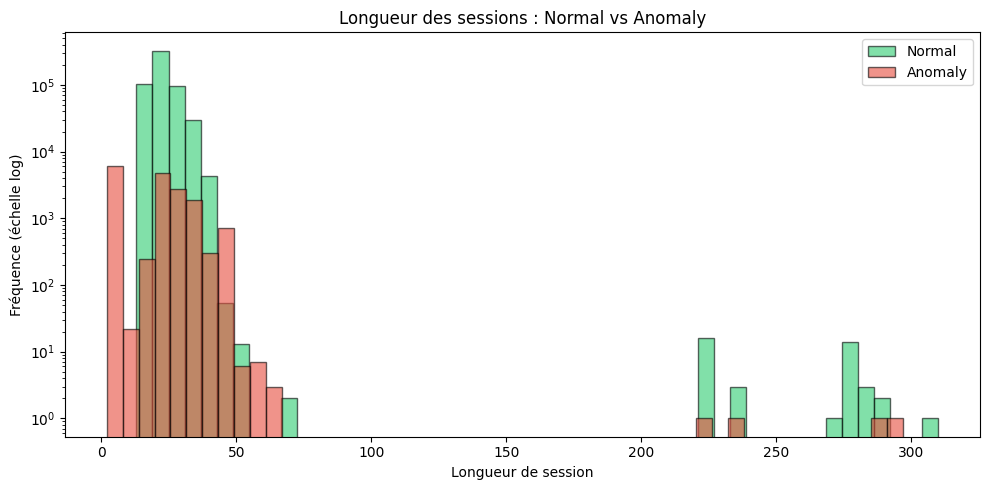

In [20]:
# Comparaison des longueurs
normal_lens = [len(s['events']) for s in enriched_sessions.values() if s['label'] == 'Normal']
anomaly_lens = [len(s['events']) for s in enriched_sessions.values() if s['label'] == 'Anomaly']

print(f"Normal  — Moyenne: {np.mean(normal_lens):.1f}, Médiane: {np.median(normal_lens):.1f}")
print(f"Anomaly — Moyenne: {np.mean(anomaly_lens):.1f}, Médiane: {np.median(anomaly_lens):.1f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(normal_lens, bins=50, alpha=0.6, label='Normal', color='#2ecc71', edgecolor='black')
ax.hist(anomaly_lens, bins=50, alpha=0.6, label='Anomaly', color='#e74c3c', edgecolor='black')
ax.set_xlabel('Longueur de session')
ax.set_ylabel('Fréquence (échelle log)')
ax.set_yscale('log')
ax.set_title('Longueur des sessions : Normal vs Anomaly')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "normal_vs_anomaly_length.png"))
plt.show()


## 5. Division train/test et sauvegarde

In [21]:
from sklearn.model_selection import train_test_split

# Préparation au format ML
block_ids = list(enriched_sessions.keys())
sequence_strings = [enriched_sessions[bid]['sequence_str'] for bid in block_ids]
labels = [1 if enriched_sessions[bid]['label'] == 'Anomaly' else 0 for bid in block_ids]

print(f"Nombre total d'échantillons : {len(block_ids):,}")
print(f"  Normal (0)  : {len(labels) - sum(labels):,}")
print(f"  Anomaly (1) : {sum(labels):,}")


Nombre total d'échantillons : 575,061
  Normal (0)  : 558,223
  Anomaly (1) : 16,838


In [ ]:
# Affichage de tous les templates, triés par fréquence
print(f"{'ID':>5} | {'Occurrences':>12} | Template")
print("-" * 90)

template_mapping = {}

for cluster in sorted(clusters, key=lambda c: c.size, reverse=True):
    eid = f"E{cluster.cluster_id}"
    template = cluster.get_template()
    template_mapping[cluster.cluster_id] = template
    print(f"{eid:>5} | {cluster.size:>12,} | {template}")


   ID |  Occurrences | Template
------------------------------------------------------------------------------------------
   E1 |    1,723,232 | Receiving block <*> src: <*> dest: <*>
   E5 |    1,719,741 | BLOCK* NameSystem.addStoredBlock: blockMap updated: <*> is added to <*> size <*>
   E3 |    1,706,728 | PacketResponder <*> for block <*> <*>
   E4 |    1,706,514 | Received block <*> of size <*> from <*>
  E17 |    1,402,047 | Deleting block <*> file <*>
  E32 |    1,396,174 | BLOCK* NameSystem.delete: <*> is added to invalidSet of <*>
   E2 |      575,061 | BLOCK* NameSystem.allocateBlock: <*> <*>
  E10 |      428,726 | <*> Served block <*> to <*>
  E35 |      356,207 | <*> exception while serving <*> to <*>
  E13 |      120,036 | Verification succeeded for <*>
   E6 |        7,097 | Received block <*> src: <*> dest: <*> of size <*>
   E7 |        6,937 | <*> block <*> to <*>
  E11 |        6,837 | BLOCK* ask <*> to replicate <*> to datanode(s) <*>
  E12 |        6,837 | <*> Star

In [22]:
# Division stratifiée train/test
# ces indices sont partagés entre TOUS les Tiers
train_idx, test_idx = train_test_split(
    list(range(len(block_ids))),
    test_size=0.2,
    stratify=labels,
    random_state=42
)

y_train = [labels[i] for i in train_idx]
y_test = [labels[i] for i in test_idx]

print(f"Train : {len(train_idx):,}  (Anomaly: {sum(y_train):,}, {sum(y_train)/len(y_train)*100:.2f}%)")
print(f"Test  : {len(test_idx):,}  (Anomaly: {sum(y_test):,}, {sum(y_test)/len(y_test)*100:.2f}%)")


Train : 460,048  (Anomaly: 13,470, 2.93%)
Test  : 115,013  (Anomaly: 3,368, 2.93%)


In [ ]:
# Sauvegarde de toutes les données prétraitées

# 1. Sessions enrichies complètes
with open(os.path.join(OUTPUT_DIR, "parsed_sessions.pkl"), 'wb') as f:
    pickle.dump(enriched_sessions, f)
print(" parsed_sessions.pkl sauvegardé")

# 2. Indices train/test partagés (pour tous les Tiers)
split_data = {
    'block_ids': block_ids,
    'train_idx': train_idx,
    'test_idx': test_idx,
    'labels': labels,
    'sequence_strings': sequence_strings
}
with open(os.path.join(OUTPUT_DIR, "train_test_split.pkl"), 'wb') as f:
    pickle.dump(split_data, f)
print("rain_test_split.pkl sauvegardé")

print(f"\n{'=' * 55}")
print("Fichiers de sortie :")
print(f"{'=' * 55}")
print(f"  outputs/template_mapping.json — {len(template_mapping)} templates")
print(f"  outputs/parsed_sessions.pkl   — {len(enriched_sessions):,} sessions")
print(f"  outputs/train_test_split.pkl  — indices train/test partagés")
print(f"  outputs/*.png                 — visualisations")
